In [1]:
from functions_newparams import *

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages

%matplotlib widget

import corner
import h5py

import warnings
warnings.filterwarnings("ignore")

SHEN FIT CHI2 GRIDS:

5 Redshift values with M*crit vs post-disk sigma.

5.326310719968742 (array([6]), array([14]), array([9]))
2.357142857142857 4.0 10.428571428571429
5.608504575457989 (array([4]), array([2]), array([8]))
2.071428571428571 2.2857142857142856 10.214285714285714
15.25560758371838 (array([2]), array([6]), array([8]))
1.7857142857142856 2.857142857142857 10.214285714285714
10.738697997832961 (array([3]), array([8]), array([7]))
1.9285714285714286 3.142857142857143 10.0
8.10482219343844 (array([3]), array([13]), array([5]))
1.9285714285714286 3.8571428571428568 9.571428571428571


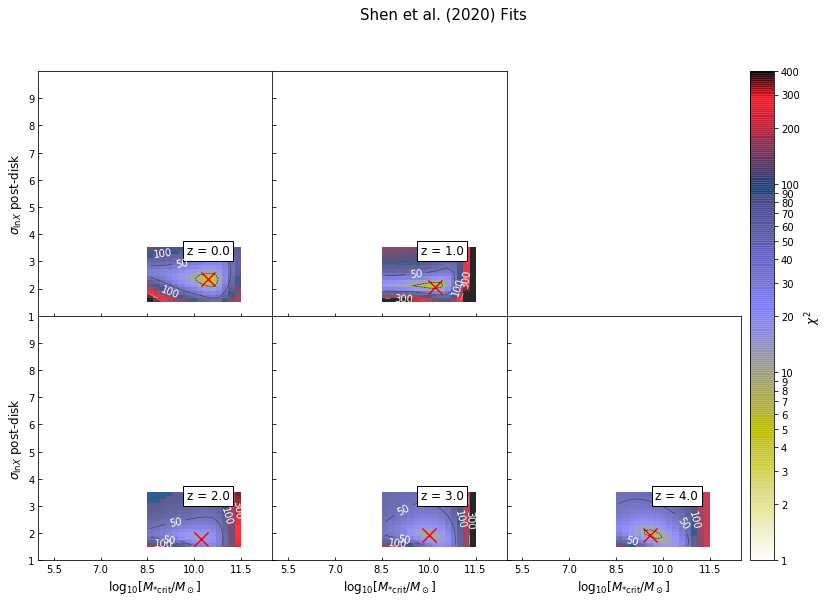

In [16]:
def CHI2_POSTvsCRIT(FILE = "output/chi2_3pShenfit_15_nw_mk3.h5py"):
    fig = plt.figure(figsize=(15,9))
    gs = gridspec.GridSpec(2, 3)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.0,1.0,2.0,3.0,4.0]
    axi = [0,0,1,1,1]
    axj = [0,1,0,1,2]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)

    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)

                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
        axis = [5,12.5,1.0,10.0]
        extent = [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.axis(axis)
        ax.tick_params(axis='both', direction='in')
        plt.setp(ax, xticks=np.linspace(5.5,11.5,5),
        yticks=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
        
        grid2d = chi23d[:,minind[1][0],:]
        ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 1, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        ax.text(9.75,3.25,'z = '+str(z), bbox=props, fontsize=12)

    
    plt.suptitle('Shen et al. (2020) Fits',fontsize=15)        
    plt.subplots_adjust(wspace=0, hspace=0)
    
    plt.setp(axes_l[0].get_xticklabels(), visible=False)  
    plt.setp(axes_l[1].get_xticklabels(), visible=False)       
    
    axes_l[2].set_xlabel(xlabel,fontsize=12)
    axes_l[3].set_xlabel(xlabel,fontsize=12)
    axes_l[4].set_xlabel(xlabel,fontsize=12)
    axes_l[0].set_ylabel(ylabel,fontsize=12)
    axes_l[2].set_ylabel(ylabel,fontsize=12)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, format="%d").set_label(label=r'$\chi ^2$ ',size=12)

    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r15_post-v-crit.pdf')


CHI2_POSTvsCRIT()


SHEN FIT CHI2 GRIDS:

5 Redshift values with M*crit vs pre-disk sigma.

5.326310719968742 (array([6]), array([14]), array([9]))
2.357142857142857 4.0 10.428571428571429
5.608504575457989 (array([4]), array([2]), array([8]))
2.071428571428571 2.2857142857142856 10.214285714285714
15.25560758371838 (array([2]), array([6]), array([8]))
1.7857142857142856 2.857142857142857 10.214285714285714
10.738697997832961 (array([3]), array([8]), array([7]))
1.9285714285714286 3.142857142857143 10.0
8.10482219343844 (array([3]), array([13]), array([5]))
1.9285714285714286 3.8571428571428568 9.571428571428571


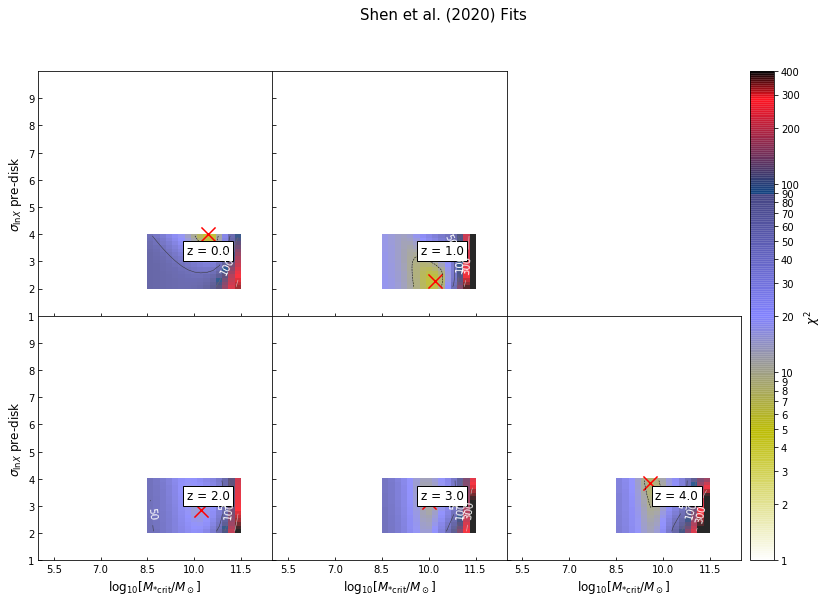

In [19]:
def CHI2_POSTvsCRIT(FILE = "output/chi2_3pShenfit_15_nw_mk3.h5py"):
    fig = plt.figure(figsize=(15,9))
    gs = gridspec.GridSpec(2, 3)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.0,1.0,2.0,3.0,4.0]
    axi = [0,0,1,1,1]
    axj = [0,1,0,1,2]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)

    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)

                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ pre-disk'
        xlabel = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
        axis = [5,12.5,1.0,10.0]
        extent = [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.axis(axis)
        ax.tick_params(axis='both', direction='in')
        plt.setp(ax, xticks=np.linspace(5.5,11.5,5),
        yticks=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
        
        grid2d = chi23d[minind[0][0],:,:]
        ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 1, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        ax.text(9.75,3.25,'z = '+str(z), bbox=props, fontsize=12)

    
    plt.suptitle('Shen et al. (2020) Fits',fontsize=15)        
    plt.subplots_adjust(wspace=0, hspace=0)
    
    plt.setp(axes_l[0].get_xticklabels(), visible=False)  
    plt.setp(axes_l[1].get_xticklabels(), visible=False)       
    
    axes_l[2].set_xlabel(xlabel,fontsize=12)
    axes_l[3].set_xlabel(xlabel,fontsize=12)
    axes_l[4].set_xlabel(xlabel,fontsize=12)
    axes_l[0].set_ylabel(ylabel,fontsize=12)
    axes_l[2].set_ylabel(ylabel,fontsize=12)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, format="%d").set_label(label=r'$\chi ^2$ ',size=12)

    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r15_pre-v-crit.pdf')


CHI2_POSTvsCRIT()


SHEN FIT CHI2 GRIDS:

5 Redshift values withpre-disk sigma vs post-disk sigma.

5.326310719968742 (array([6]), array([14]), array([9]))
2.357142857142857 4.0 10.428571428571429
5.608504575457989 (array([4]), array([2]), array([8]))
2.071428571428571 2.2857142857142856 10.214285714285714
15.25560758371838 (array([2]), array([6]), array([8]))
1.7857142857142856 2.857142857142857 10.214285714285714
10.738697997832961 (array([3]), array([8]), array([7]))
1.9285714285714286 3.142857142857143 10.0
8.10482219343844 (array([3]), array([13]), array([5]))
1.9285714285714286 3.8571428571428568 9.571428571428571


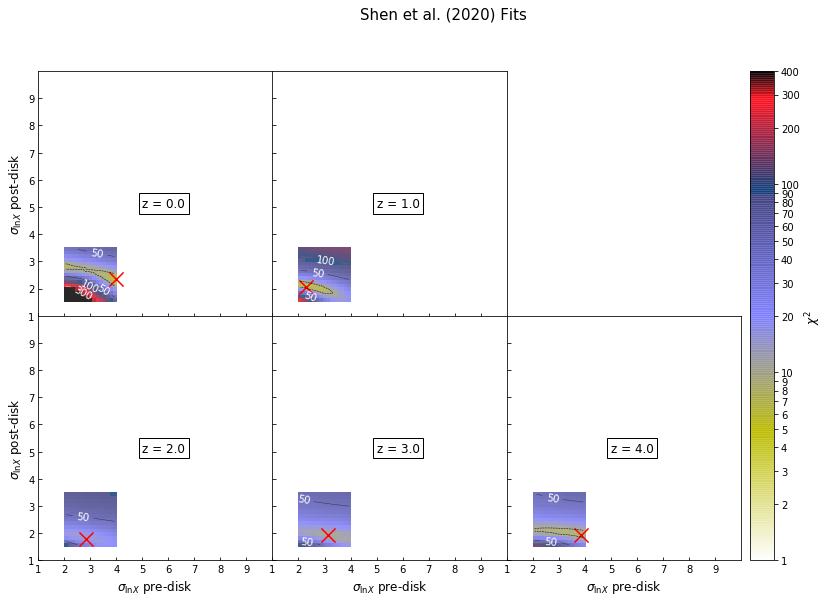

In [22]:
def CHI2_POSTvsCRIT(FILE = "output/chi2_3pShenfit_15_nw_mk3.h5py"):
    fig = plt.figure(figsize=(15,9))
    gs = gridspec.GridSpec(2, 3)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.0,1.0,2.0,3.0,4.0]
    axi = [0,0,1,1,1]
    axj = [0,1,0,1,2]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)

    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)

                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = r'$\sigma_{\ln{X}}$ pre-disk'
        axis = [1.0,10.0,1.0,10.0]
        extent = [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.axis(axis)
        ax.tick_params(axis='both', direction='in')
        plt.setp(ax, xticks=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0],
        yticks=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
        
        grid2d = chi23d[:,:,minind[2][0]]
        ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 1, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        ax.text(5,5,'z = '+str(z), bbox=props, fontsize=12)

    
    plt.suptitle('Shen et al. (2020) Fits',fontsize=15)        
    plt.subplots_adjust(wspace=0, hspace=0)
    
    plt.setp(axes_l[0].get_xticklabels(), visible=False)  
    plt.setp(axes_l[1].get_xticklabels(), visible=False)       
    
    axes_l[2].set_xlabel(xlabel,fontsize=12)
    axes_l[3].set_xlabel(xlabel,fontsize=12)
    axes_l[4].set_xlabel(xlabel,fontsize=12)
    axes_l[0].set_ylabel(ylabel,fontsize=12)
    axes_l[2].set_ylabel(ylabel,fontsize=12)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, format="%d").set_label(label=r'$\chi ^2$ ',size=12)

    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r15_pre-v-post.pdf')


CHI2_POSTvsCRIT()


AIRD FIT CHI2 GRIDS:

All redshift values with M*crit vs post-disk sigma.